In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import escher

In [27]:
df_final = pd.read_csv("cafba_sweep_results.csv", index_col=0)

In [28]:
df_final

,w_c,growth_rate,phi_C,phi_E,phi_R,flux_PFK,flux_EDD,flux_glc
0,0.000000,0.621898,0.000000,0.395060,0.171723,1.495285,2.959143,10.000000
1,0.000102,0.620619,0.001020,0.394239,0.171505,1.520256,3.001671,10.000000
2,0.000210,0.619263,0.002102,0.393367,0.171275,1.546726,3.046751,10.000000
3,0.000331,0.617753,0.003306,0.392398,0.171018,1.576192,3.096934,10.000000
4,0.000469,0.616014,0.004693,0.391280,0.170722,1.610153,3.154773,10.000000
...,...,...,...,...,...,...,...,...
95,0.884379,0.061086,0.429940,0.043757,0.076385,0.428561,0.008368,0.486149
96,0.912397,0.059414,0.431419,0.042559,0.076100,0.416831,0.008139,0.472842
97,0.941002,0.057799,0.432849,0.041402,0.075826,0.405499,0.007918,0.459987
98,0.970201,0.056238,0.434230,0.040284,0.075560,0.394550,0.007704,0.447567


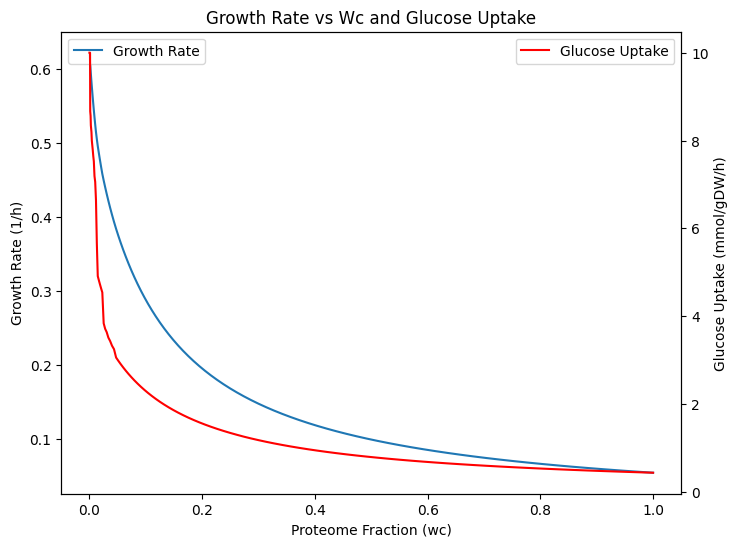

In [29]:
# Plot wc versus growth rate and the glucose uptake flux on the same graph with two y axis (growth rate on left, glucose uptake on right)
plt.figure(figsize=(8, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_final['w_c'], df_final['growth_rate'], label='Growth Rate')
ax2.plot(df_final['w_c'], df_final['flux_glc'], label='Glucose Uptake', color='red')

ax1.set_xlabel('Proteome Fraction (wc)')
ax1.set_ylabel('Growth Rate (1/h)')
ax2.set_ylabel('Glucose Uptake (mmol/gDW/h)')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Growth Rate vs Wc and Glucose Uptake')

# Save the plot
plt.savefig("cafba_wc_growth_rate.png", dpi=300)
plt.show()

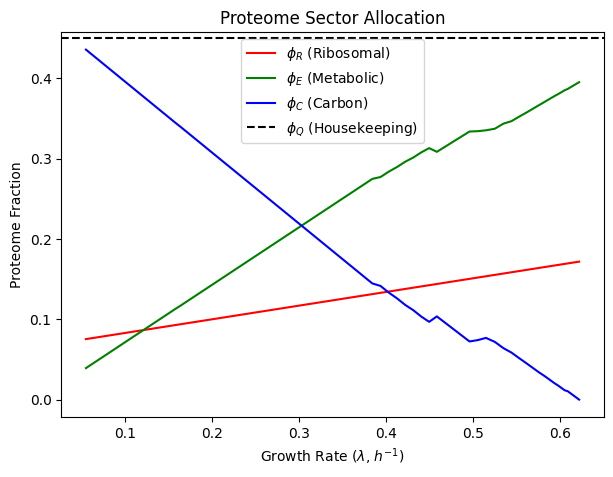

In [30]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['phi_R'], color='red', label='$\phi_R$ (Ribosomal)')
plt.plot(df_final['growth_rate'], df_final['phi_E'], color='green', label='$\phi_E$ (Metabolic)')
plt.plot(df_final['growth_rate'], df_final['phi_C'], color='blue', label='$\phi_C$ (Carbon)')
plt.axhline(y=PHI_Q, color='black', linestyle='--', label='$\phi_Q$ (Housekeeping)')
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Proteome Fraction')
plt.legend()
plt.title('Proteome Sector Allocation')

# Save the plot
plt.savefig("cafba_proteome_allocation.png", dpi=300)
plt.show()

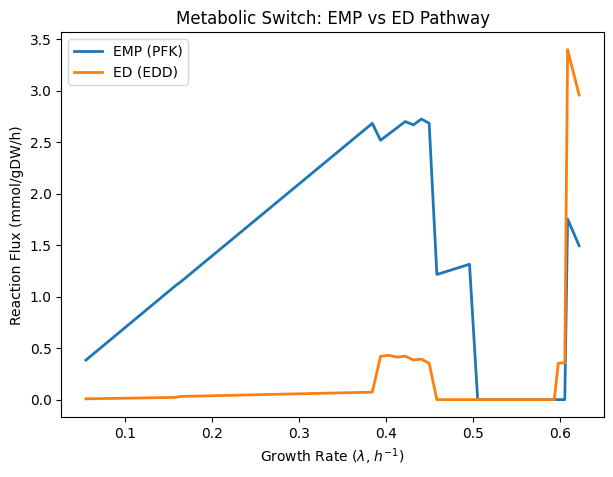

In [31]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['flux_PFK'], label='EMP (PFK)', linewidth=2)
plt.plot(df_final['growth_rate'], df_final['flux_EDD'], label='ED (EDD)', linewidth=2)
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Reaction Flux (mmol/gDW/h)')
plt.title('Metabolic Switch: EMP vs ED Pathway')
plt.legend()

# Save the plot
plt.savefig("cafba_emp_ed_fluxes.png", dpi=300)
plt.show()

In [32]:
# Save the path to the Escher map (with glycolysis and TCA cycle)
amac_map_path = "../../escher/MIT1002_glycolysis_and_tca_escher-map.json"

In [34]:
# Read the flux results from a json file
with open("results/json_fluxes/cafba_fluxes_wc_0.0000.json", "r") as f:
    flux_data = json.load(f)
# Make map with the solution for a single time point
builder = escher.Builder(
    map_json=amac_map_path
)
builder.reaction_data = flux_data
builder
# Then save the map manually from the widget

Builder(reaction_data={'rxn02201_c0': 0.004002634247751011, 'rxn00351_c0': 0.0, 'rxn07431_c0': 0.0, 'rxn00836_…

In [36]:
# Read the flux results from a json file
with open("results/json_fluxes/cafba_fluxes_wc_0.0554.json", "r") as f:
    flux_data = json.load(f)
# Make map with the solution for a single time point
builder = escher.Builder(
    map_json=amac_map_path
)
builder.reaction_data = flux_data
builder
# Then save the map manually from the widget

Builder(reaction_data={'rxn02201_c0': 0.0023509530163566945, 'rxn00351_c0': 0.0, 'rxn07431_c0': 0.0, 'rxn00836…

In [35]:
# Read the flux results from a json file
with open("results/json_fluxes/cafba_fluxes_wc_1.0000.json", "r") as f:
    flux_data = json.load(f)
# Make map with the solution for a single time point
builder = escher.Builder(
    map_json=amac_map_path
)
builder.reaction_data = flux_data
builder
# Then save the map manually from the widget

Builder(reaction_data={'rxn02201_c0': 0.00035225143911786396, 'rxn00351_c0': 0.0, 'rxn07431_c0': -7.7161086693…